# Equity Duration – Robustness Measures

Three cross-sectional proxies for equity duration:
- **Shareholder Yield (SY):** (Dividends + Buybacks) / ME
- **Book-to-Market (B/M):** BE / ME
- **Earnings-to-Price (E/P):** NetIncome / ME

Input: `euro500_netpayout.parquet`  
Output: `EQDuration_Robustness.parquet`

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from plot_style import COLORS, set_global_plot_style, style_axes
from project_paths import BASE_DIR, DATA_DIR

set_global_plot_style()


def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")


def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

In [2]:
raw = load_parquet("euro500_netpayout").copy()

# --- Parse dates & identifiers ---
raw["firm_id"] = raw["firm_id"].astype(str).str.strip()

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["year"] = raw["date"].dt.year
elif "effective_date" in raw.columns:
    raw["effective_date"] = pd.to_datetime(raw["effective_date"], errors="coerce")
    raw["year"] = raw["effective_date"].dt.year
elif "year" not in raw.columns:
    raise KeyError("Input needs date, effective_date, or year column")

raw["year"] = pd.to_numeric(raw["year"], errors="coerce").astype("Int64")

# --- Aggregate to annual: latest observation per firm-year ---
sort_col = "date" if "date" in raw.columns else "effective_date"
raw = raw.sort_values(["firm_id", "year", sort_col], na_position="first")
ann = raw.groupby(["firm_id", "year"], as_index=False).last()
ann["year"] = ann["year"].astype(int)

# --- Ensure CashSTInvst exists ---
if "CashSTInvst" not in ann.columns:
    ann["CashSTInvst"] = np.nan

# --- Lagged variables within firm ---
ann = ann.sort_values(["firm_id", "year"])
for col in ["BE", "Sales"]:
    if col in ann.columns:
        ann[f"{col}_lag1"] = ann.groupby("firm_id")[col].shift(1)

# ME_t = mcap_eur (already in EUR)
ann["ME_t"] = pd.to_numeric(ann["mcap_eur"], errors="coerce")

print(f"Shape (firm-year panel): {ann.shape}")
print(f"Firms: {ann['firm_id'].nunique():,}   Years: {sorted(ann['year'].unique())}")
print(f"Date range: {ann['year'].min()} – {ann['year'].max()}")

# --- Coverage diagnostics ---
cov_cols = ["ME_t", "BE", "NetIncome", "Dividends", "Buybacks", "CashSTInvst"]
cov = {c: ann[c].notna().sum() if c in ann.columns else 0 for c in cov_cols}
print("\nNon-null counts per key column:")
for c, n in cov.items():
    print(f"  {c:<16} {n:>6,}  ({100*n/len(ann):.1f}%)")

Shape (firm-year panel): (16858, 17)
Firms: 1,125   Years: [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Date range: 1995 – 2025

Non-null counts per key column:
  ME_t             15,763  (93.5%)
  BE               16,743  (99.3%)
  NetIncome        16,548  (98.2%)
  Dividends        13,268  (78.7%)
  Buybacks         10,515  (62.4%)
  CashSTInvst      16,012  (95.0%)


## 2. Shareholder Yield

Three variants:

$$
\text{SY}_{\text{gross}} = \frac{\text{Dividends} + \text{Buybacks}}{\text{ME}_t}
\qquad
\text{SY}_{\text{div\_only}} = \frac{\text{Dividends}}{\text{ME}_t}
\qquad
\text{SY}_{\text{adj}} = \frac{\text{Dividends} + \text{Buybacks} - \text{CashSTInvst}}{\text{ME}_t}
$$

Sign convention: LSEG reports Dividends/Buybacks as positive outflows; `abs()` guards against
occasional sign flips in the source data.

> **Note on SY\_adj:** `CashSTInvst` is cash invested in short-term instruments, not a direct
> measure of equity issuance. `SY_adj` should be treated as an exploratory variant, not a clean
> net-payout measure.

In [3]:
def _winsorize_cross_section(series: pd.Series, groups: pd.Series,
                              lo: float = 0.01, hi: float = 0.99) -> pd.Series:
    """Winsorize at lo/hi quantiles cross-sectionally within each group."""
    out = series.copy().astype(float)
    for grp, idx in groups.groupby(groups).groups.items():
        vals = out.loc[idx]
        q_lo = vals.quantile(lo)
        q_hi = vals.quantile(hi)
        out.loc[idx] = vals.clip(lower=q_lo, upper=q_hi)
    return out


# --- Sign-safe payout components ---
div = pd.to_numeric(ann["Dividends"], errors="coerce").abs() if "Dividends" in ann.columns else pd.Series(np.nan, index=ann.index)
bb  = pd.to_numeric(ann["Buybacks"],  errors="coerce").abs() if "Buybacks"  in ann.columns else pd.Series(np.nan, index=ann.index)
csi = pd.to_numeric(ann["CashSTInvst"], errors="coerce")      if "CashSTInvst" in ann.columns else pd.Series(np.nan, index=ann.index)

# --- Shareholder Yield variants ---

# Variant 1: Gross (Dividends + Buybacks)
# fill_value=0 only where Dividends exist but Buybacks are missing —
# treats missing Buybacks as 'no repurchases' (conservative)
total_payout = div.add(bb, fill_value=0)
ann["SY_gross"] = total_payout / ann["ME_t"]

# Variant 2: Dividends only — higher coverage, more stable for early years
# and firms without buyback reporting
ann["SY_div_only"] = div / ann["ME_t"]

# Variant 3: SY_adj — payout minus CashSTInvst as a rough proxy for
# operating distributions net of cash-management effects.
# NOTE: CashSTInvst is NOT a direct measure of equity issuance;
# SY_adj is exploratory, not a clean net-payout measure.
ann["SY_adj"] = (total_payout - csi.fillna(0)) / ann["ME_t"]

# Mask where ME_t <= 0 or missing
me_invalid = ann["ME_t"].isna() | (ann["ME_t"] <= 0)
ann.loc[me_invalid, ["SY_gross", "SY_div_only", "SY_adj"]] = np.nan

# Flag: Buybacks missing (cannot be safely imputed as 0)
ann["flag_sy_buybacks_missing"] = (div.notna() & bb.isna()).astype("Int8")

# --- Winsorize at 1%/99% by year ---
for col in ["SY_gross", "SY_div_only", "SY_adj"]:
    ann[f"{col}_w"] = _winsorize_cross_section(ann[col], ann["year"])

ann["flag_sy_negative"] = (ann["SY_gross"] < 0).astype("Int8")

# --- Diagnostics ---
print("SY_gross descriptive stats:")
print(ann["SY_gross"].describe().round(4))
print(f"\nSY_div_only vs SY_gross coverage:")
print(f"  SY_gross    non-null: {ann['SY_gross'].notna().sum():,}  "
      f"({100*ann['SY_gross'].notna().mean():.1f}%)")
print(f"  SY_div_only non-null: {ann['SY_div_only'].notna().sum():,}  "
      f"({100*ann['SY_div_only'].notna().mean():.1f}%)")
print(f"\nBuybacks missing (flag_sy_buybacks_missing): "
      f"{ann['flag_sy_buybacks_missing'].sum():,} obs "
      f"({100*ann['flag_sy_buybacks_missing'].mean():.1f}%)")
print("\nCorrelation SY_gross vs SY_div_only "
      "(quantifies buyback contribution):")
_valid_sy = ann[["SY_gross", "SY_div_only"]].dropna()
print(f"  Pearson  = {_valid_sy['SY_gross'].corr(_valid_sy['SY_div_only']):.3f}")
print(f"\nNegative SY_gross: {ann['flag_sy_negative'].sum():,} ({100*ann['flag_sy_negative'].mean():.1f}%)")

SY_gross descriptive stats:
count    14156.0
mean      0.0634
std       0.3796
min          0.0
25%       0.0155
50%       0.0317
75%       0.0597
max      28.8692
Name: SY_gross, dtype: Float64

Negative SY_gross: 0 (0.0%)
Non-null SY_gross: 14,156
Non-null SY_net:   14,156


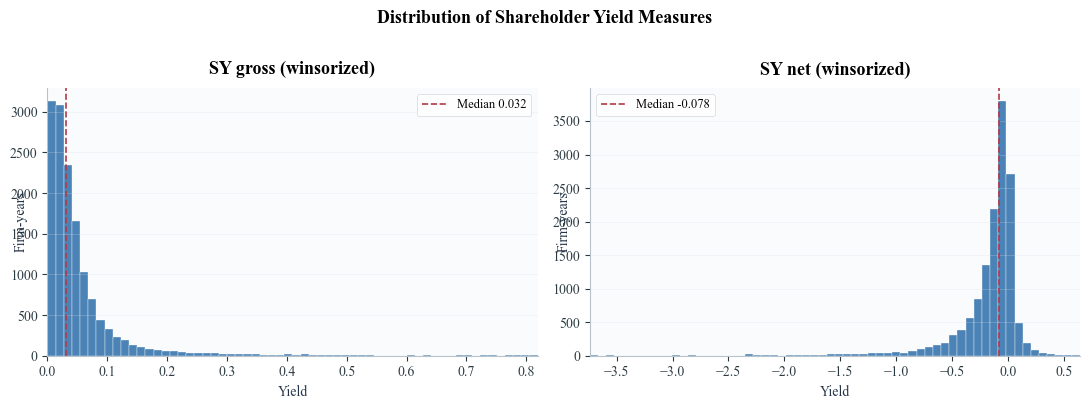

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ["SY_gross_w", "SY_div_only_w", "SY_adj_w"],
    ["SY gross (winsorized)", "SY dividends-only (winsorized)", "SY adj (winsorized)"],
):
    data = ann[col].dropna()
    ax.hist(data, bins=60, color=COLORS["blue"], edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(data.median(), color=COLORS["accent"], linewidth=1.2, linestyle="--",
               label=f"Median {data.median():.3f}")
    ax.set_title(label)
    ax.set_xlabel("Yield")
    ax.set_ylabel("Firm-years")
    style_axes(ax)
    ax.legend(fontsize=9)

fig.suptitle("Distribution of Shareholder Yield Measures", y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

## 3. Book-to-Market (B/M)

$$
\text{B/M}_{i,t} = \frac{\text{BE}_{i,t}}{\text{ME}_t}
$$

Requires $\text{BE} > 0$ and $\text{ME}_t > 0$.

In [5]:
be = pd.to_numeric(ann["BE"], errors="coerce") if "BE" in ann.columns else pd.Series(np.nan, index=ann.index)

bm_raw = be / ann["ME_t"]
# Require both BE > 0 and ME_t > 0
bm_raw = bm_raw.where((be > 0) & (ann["ME_t"] > 0))

ann["BM"] = bm_raw
ann["BM_w"] = _winsorize_cross_section(ann["BM"], ann["year"])

print("B/M descriptive stats:")
print(ann["BM"].describe().round(4))
print(f"\nNon-null B/M: {ann['BM'].notna().sum():,}")

# Correlation with SY_gross (expected: positive — both are short-duration proxies;
# value firms (high B/M) tend to pay out more (high SY), consistent with DSS)
valid = ann[["BM", "SY_gross"]].dropna()
corr = valid["BM"].corr(valid["SY_gross"])
print(f"\nCorr(B/M, SY_gross) = {corr:.3f}  (expected: positive — both are short-duration proxies)")

B/M descriptive stats:
count    15563.0
mean      0.8804
std       5.7182
min       0.0002
25%       0.3339
50%        0.576
75%       0.9498
max      479.979
Name: BM, dtype: Float64

Non-null B/M: 15,563

Corr(B/M, SY_gross) = 0.431  (expected: negative)


## 4. Earnings-to-Price (E/P)

$$
\text{E/P}_{i,t} = \frac{\text{NetIncome}_{i,t}}{\text{ME}_t}
$$

Negative E/P (loss firms) is retained.

In [6]:
ni = pd.to_numeric(ann["NetIncome"], errors="coerce") if "NetIncome" in ann.columns else pd.Series(np.nan, index=ann.index)

ep_raw = ni / ann["ME_t"]
ep_raw = ep_raw.where(ann["ME_t"] > 0)  # only require valid ME_t

ann["EP"] = ep_raw
ann["EP_w"] = _winsorize_cross_section(ann["EP"], ann["year"])

print("E/P descriptive stats:")
print(ann["EP"].describe().round(4))
print(f"\nLoss firms (EP < 0): {(ann['EP'] < 0).sum():,} ({100*(ann['EP'] < 0).mean():.1f}%)")
print(f"Non-null E/P: {ann['EP'].notna().sum():,}")

# Correlations
valid3 = ann[["EP", "BM", "SY_gross"]].dropna()
print(f"\nCorr(E/P, B/M)      = {valid3['EP'].corr(valid3['BM']):.3f}")
print(f"Corr(E/P, SY_gross) = {valid3['EP'].corr(valid3['SY_gross']):.3f}")

E/P descriptive stats:
count    15466.0
mean      0.0554
std        0.975
min     -30.3583
25%        0.031
50%       0.0589
75%       0.0948
max      81.5905
Name: EP, dtype: Float64

Loss firms (EP < 0): 1,742 (11.3%)
Non-null E/P: 15,466

Corr(E/P, B/M)      = 0.828
Corr(E/P, SY_gross) = 0.283


## 5. Quality Screens & Sample Diagnostics

In [7]:
N0 = len(ann)
print(f"Starting sample: {N0:,} firm-years")
print()

screens = [
    ("ME_t > 0",           ann["ME_t"].notna() & (ann["ME_t"] > 0)),
    ("BE > 0",             be.notna() & (be > 0)),
    ("Finite NetIncome",   ni.notna() & np.isfinite(ni)),
    ("≥1 measure valid",   ann["SY_gross"].notna() | ann["SY_div_only"].notna() | ann["BM"].notna() | ann["EP"].notna()),
]

mask = pd.Series(True, index=ann.index)
rows = []
for label, condition in screens:
    before = mask.sum()
    mask = mask & condition
    after = mask.sum()
    rows.append({"Screen": label, "Before": before, "After": after, "Dropped": before - after})

screen_df = pd.DataFrame(rows)
print(screen_df.to_string(index=False))
print(f"\nFinal analytic sample: {mask.sum():,} firm-years")

# By-year coverage
print("\nBy-year non-null counts:")
coverage = ann.groupby("year")[["SY_gross", "SY_div_only", "BM", "EP"]].count()
print(coverage.to_string())

# By-sector if available
sector_col = next((c for c in ["sector", "Sector", "gics_sector", "industry"] if c in ann.columns), None)
if sector_col:
    print(f"\nBy-sector coverage ({sector_col}):")
    sec_cov = ann.groupby(sector_col)[["SY_gross", "SY_div_only", "BM", "EP"]].count()
    print(sec_cov.to_string())
else:
    print("\n[INFO] No sector column found – skipping sector breakdown.")

Starting sample: 16,858 firm-years

          Screen  Before  After  Dropped
        ME_t > 0   16858  15763     1095
          BE > 0   15763  15563      200
Finite NetIncome   15563  15273      290
≥1 measure valid   15273  15273        0

Final analytic sample: 15,273 firm-years

By-year non-null counts:
      SY_gross   BM   EP
year                    
1995         0    4    3
1996       140  222  222
1997       199  319  315
1998       282  450  441
1999       361  514  508
2000       408  535  528
2001       415  542  537
2002       408  527  522
2003       437  550  539
2004       506  545  545
2005       525  550  551
2006       548  568  564
2007       579  598  592
2008       568  587  586
2009       558  584  576
2010       562  585  576
2011       556  563  567
2012       544  558  560
2013       543  565  562
2014       542  560  558
2015       545  567  564
2016       547  562  561
2017       563  576  571
2018       566  577  574
2019       556  574  572
2020       553  

## 6. Correlation Matrix & Validation

In [8]:
measures = ["SY_gross_w", "SY_div_only_w", "SY_adj_w", "BM_w", "EP_w"]
corr_df = ann[measures].dropna()

pearson  = corr_df.corr(method="pearson")
spearman = corr_df.corr(method="spearman")

print("Pearson correlation:")
print(pearson.round(3).to_string())
print("\nSpearman rank correlation:")
print(spearman.round(3).to_string())

# Flag redundant pairs
print("\nRedundancy check (|Pearson| > 0.8):")
found = False
for i, c1 in enumerate(measures):
    for c2 in measures[i+1:]:
        v = abs(pearson.loc[c1, c2])
        if v > 0.8:
            print(f"  [WARN] {c1} vs {c2}: r = {v:.3f}")
            found = True
if not found:
    print("  None – no pair exceeds 0.8.")

Pearson correlation:
            SY_gross_w  SY_net_w   BM_w   EP_w
SY_gross_w       1.000     0.065  0.295  0.040
SY_net_w         0.065     1.000 -0.361 -0.017
BM_w             0.295    -0.361  1.000  0.087
EP_w             0.040    -0.017  0.087  1.000

Spearman rank correlation:
            SY_gross_w  SY_net_w   BM_w   EP_w
SY_gross_w       1.000     0.181  0.259  0.248
SY_net_w         0.181     1.000 -0.268 -0.077
BM_w             0.259    -0.268  1.000  0.300
EP_w             0.248    -0.077  0.300  1.000

Redundancy check (|Pearson| > 0.8):
  None – no pair exceeds 0.8.


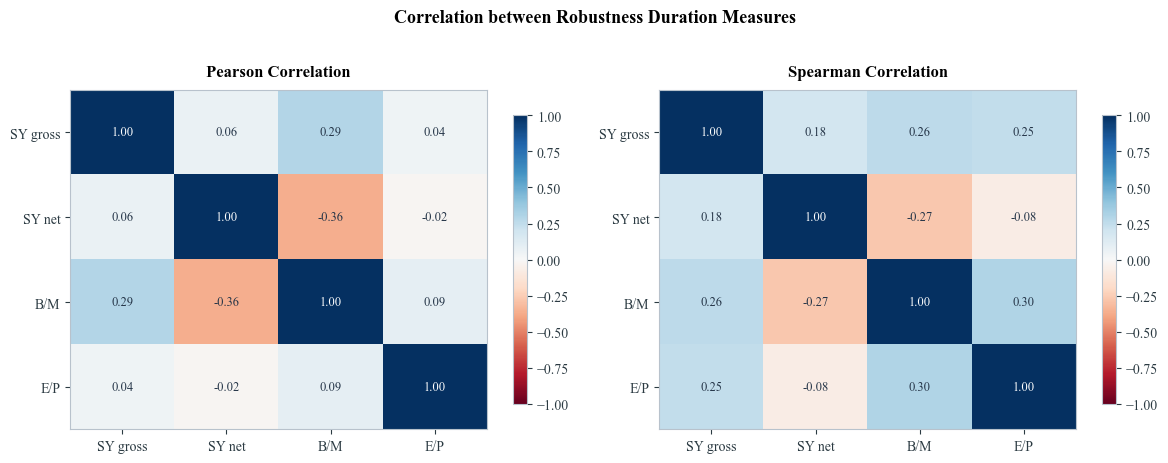

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["SY gross", "SY div-only", "SY adj", "B/M", "E/P"]

for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="RdBu", aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9, rotation=30, ha="right")
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"{title} Correlation", fontsize=12, fontweight="semibold")
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(val) > 0.5 else "#243447")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle("Correlation between Robustness Duration Measures", y=1.02, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

## 7. Save Output

In [10]:
output_cols = [
    "firm_id", "year", "ME_t",
    # Raw measures
    "SY_gross", "SY_div_only", "SY_adj", "BM", "EP",
    # Winsorized
    "SY_gross_w", "SY_div_only_w", "SY_adj_w", "BM_w", "EP_w",
    # Flags
    "flag_sy_negative", "flag_sy_buybacks_missing",
]

out = ann[[c for c in output_cols if c in ann.columns]].copy()

out["n_measures_available"] = (
    out[["SY_gross", "BM", "EP"]]
    .notna()
    .sum(axis=1)
    .astype("Int8")
)

out = out.sort_values(["firm_id", "year"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Robustness")

print(f"\nFinal shape: {out.shape}")
print(f"Columns: {list(out.columns)}")
print("\nNon-null coverage:")
for col in ["SY_gross", "SY_div_only", "SY_adj", "BM", "EP"]:
    if col in out.columns:
        n = out[col].notna().sum()
        print(f"  {col:<16} {n:>6,}  ({100*n/len(out):.1f}%)")
print(f"\nFlag coverage:")
print(f"  flag_sy_buybacks_missing: "
      f"{out['flag_sy_buybacks_missing'].sum():,} obs")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Robustness.parquet

Final shape: (16858, 13)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_net', 'BM', 'EP', 'SY_gross_w', 'SY_net_w', 'BM_w', 'EP_w', 'flag_sy_negative', 'n_measures_available']

Non-null coverage:
  SY_gross       14,156  (84.0%)
  SY_net         14,156  (84.0%)
  BM             15,563  (92.3%)
  EP             15,466  (91.7%)
  SY_gross_w     14,156  (84.0%)
  SY_net_w       14,156  (84.0%)
  BM_w           15,563  (92.3%)
  EP_w           15,466  (91.7%)


## 8. Interpretation

### What was computed

Four firm-level proxies for **equity duration** were constructed from annual accounting and
market-cap data for the Euro 500 universe:

| Measure | Formula | Duration interpretation |
|---------|---------|------------------------|
| **SY gross** | (Dividends + Buybacks) / ME | High SY → near-term cash flows → **short** duration |
| **SY div-only** | Dividends / ME | Higher coverage; preferred for early sample years or sparse buyback data |
| **SY adj** | (Dividends + Buybacks − CashSTInvst) / ME | Exploratory; CashSTInvst ≠ equity issuance |
| **B/M** | BE / ME | Value (high B/M) → short duration; growth (low B/M) → long duration |
| **E/P** | NetIncome / ME | Earnings yield; high E/P → current profits dominate → short duration |

All measures are winsorized at 1%/99% cross-sectionally within each year.

### Expected economic signs

- **SY and B/M**: positively correlated — value firms tend to return more cash; both proxy
  short duration (consistent with DSS and Lettau & Wachter).
- **SY and E/P**: positively correlated — profitable firms pay out more.
- **B/M and E/P**: positively correlated in levels (value firms tend to be currently profitable).
- All should be **negatively** correlated with implied/long-horizon duration measures.

### Cross-sectional variation

B/M typically shows the widest cross-sectional dispersion because it reflects cumulative
retained earnings vs. market expectations of future growth. E/P is compressed by loss firms.
SY variants are mechanically bounded near zero for most firms but show meaningful
right-tail variation driven by large repurchasers. `SY_div_only` offers the widest
coverage and is recommended as the primary SY measure.

### Merge readiness

The output table `EQDuration_Robustness.parquet` contains one row per `(firm_id, year)` and
merges directly into the ECB shock regression panel via:

```python
panel.merge(robustness, on=["firm_id", "year"], how="left")
```

Use winsorized variants (`*_w`) in regressions. `SY_div_only_w` is recommended as the
primary SY measure when buyback coverage is a concern.